In [ ]:
# Conda environment: scib_metrics
# added kmeans computation
# rest of metrics as computed in Evaluate_real_data_minimal_example_optimization_clustering_resolution.ipynb

In [2]:
import scanpy as sc
import anndata as ad
import scib_metrics
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl
import seaborn as sns
import json
from matplotlib.ticker import FuncFormatter
from matplotlib.patches import Patch

/fast/AG_Ohler/prauten/conda_envs/scib_metrics/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=ad.OldFormatWarning)

In [4]:
scenarios = ['Liam_x1_minimal_example', 'Liam_x5_minimal_example', 'naiveIntegration_minimal_example', 'noIntegration_minimal_example']

In [5]:
np.random.seed(61)

# Collect computed scores, nested dict is simple to convert to pd.DataFrame
score_dict = {}
for scenario in scenarios:
    # Initialize nested dict
    score_dict[scenario] = {}
    
    adata = ad.read_h5ad('./../../embeddings/{}.embedding.h5ad'.format(scenario))
    adata.obsm['embedding'] = adata.X
    
    sc.pp.neighbors(adata, use_rep='embedding')
    
    sc.tl.umap(adata)

    
    nmi_ari_dict = scib_metrics.nmi_ari_cluster_labels_kmeans(
            adata.obsm['embedding'],
            adata.obs['cell_type'],
        )
   
    score_dict[scenario]['nmi_kmeans'], score_dict[scenario]['ari_kmeans'] = nmi_ari_dict['nmi'], nmi_ari_dict['ari']
    

In [6]:
kmeans_df = pd.DataFrame(score_dict)

In [7]:
kmeans_df

,Liam_x1_minimal_example,Liam_x5_minimal_example,naiveIntegration_minimal_example,noIntegration_minimal_example
nmi_kmeans,0.696243,0.692704,0.649675,0.592482
ari_kmeans,0.490230,0.472562,0.366104,0.314189


In [8]:
# restart kernel and start from here (imports on top)

In [9]:
with open('./../../evaluation/nmi_ari_clustering_choice_impact_real_data_minimal_example.json', 'r') as file:
    loaded_dict = json.load(file)


In [10]:
score_dict = loaded_dict

In [11]:
score_dict

{'Liam_x1_minimal_example': {'nmi': {'0.1': {'nb_clust': 8,
    'score': 0.7146557231190599},
   '0.2': {'nb_clust': 9, 'score': 0.7323623209424057},
   '0.30000000000000004': {'nb_clust': 13, 'score': 0.7387141045255413},
   '0.4': {'nb_clust': 16, 'score': 0.7475628915462355},
   '0.5': {'nb_clust': 18, 'score': 0.7482121711766023},
   '0.6': {'nb_clust': 18, 'score': 0.7407761720015943},
   '0.7000000000000001': {'nb_clust': 20, 'score': 0.747982295557692},
   '0.8': {'nb_clust': 20, 'score': 0.7464365015924751},
   '0.9': {'nb_clust': 21, 'score': 0.7519899351178838},
   '1.0': {'nb_clust': 23, 'score': 0.7375223880383233},
   '1.1': {'nb_clust': 24, 'score': 0.7363450760259338},
   '1.2000000000000002': {'nb_clust': 25, 'score': 0.7288328664749739},
   '1.3000000000000003': {'nb_clust': 29, 'score': 0.7062224995304924},
   '1.4000000000000001': {'nb_clust': 30, 'score': 0.7042249746435315},
   '1.5000000000000002': {'nb_clust': 30, 'score': 0.698130789797516},
   '1.6': {'nb_clust

In [12]:
scenarios = ['Liam_x1_minimal_example', 'Liam_x5_minimal_example', 'naiveIntegration_minimal_example', 'noIntegration_minimal_example']

In [13]:
# From https://matplotlib.org/stable/gallery/subplots_axes_and_figures/figure_size_units.html
mm = 1/25.4  # millimeters in inches

In [14]:
# overwrite scanpy/matplotlib default font: chose: Arial

In [15]:
# Need to remove chached fonts

In [16]:
! rm ~/.cache/matplotlib -rf

/fast/AG_Ohler/prauten/conda_envs/scib_metrics/lib/python3.10/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


In [17]:
font_dirs = ["/fast/AG_Ohler/prauten/conda_envs/scib_metrics/fonts"]  # The path to the custom font file.

font_files = fm.findSystemFonts(fontpaths=font_dirs)

for font_file in font_files:
    fm.fontManager.addfont(font_file)

In [18]:
# change font
plt.rcParams['font.family'] = "sans-serif"
plt.rcParams['font.sans-serif'] = "Arial"

In [19]:
plt.rcParams['lines.markersize'] = 0.5

In [20]:
# Set font sizes
mpl.rcParams['font.size'] = 7
mpl.rcParams['axes.labelsize'] = 7
mpl.rcParams['xtick.labelsize'] = 7
mpl.rcParams['ytick.labelsize'] = 7
mpl.rcParams['legend.fontsize'] = 7
mpl.rcParams['axes.titlesize'] = 7
mpl.rcParams['axes.linewidth'] = 0.5

In [21]:
#mpl.rcParams.keys()

In [23]:
adata = ad.read_h5ad('./../../embeddings/{}.embedding.h5ad'.format(scenarios[0]))

In [24]:
true_nb_clust = len(adata.obs['cell_type'].unique())

In [25]:
plt.rcParams["figure.figsize"] = (8/13*150*mm, 5/8*80*mm)

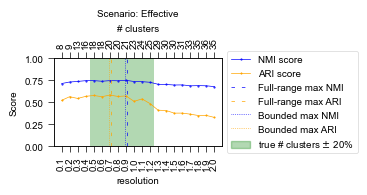

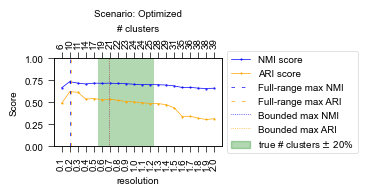

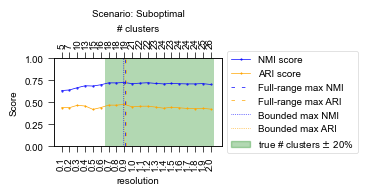

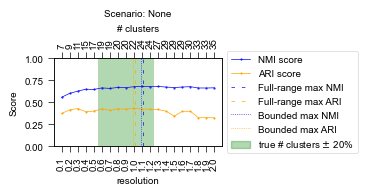

In [26]:
def create_range_around_number(a):
    """
    Creates an inclusive integer range approximately ±20% around the input number.

    Uses floor and ceil to ensure the range includes all integers within the bounds,
    even when the input or calculated bounds are not integers.

    Args:
    a (float): The central number for the range.

    Returns:
    list: A list of integers representing the inclusive range.
    """
    twenty_percent = a * 0.2
    
    # Round 20% to the nearest whole number
    rounded_range = np.round(twenty_percent)
    
    # Calculate the start and end of the range
    start = np.floor(a - rounded_range).astype(int)
    end = np.ceil(a + rounded_range).astype(int)
    
    # Create and return the range of integers as a list
    return list(np.arange(start, end + 1))

scores_to_df = {}
for scenario in scenarios:
    scores_to_df[scenario] = {}
    nmi = pd.DataFrame(score_dict[scenario]['nmi']).T
    nmi['resolution'] = nmi.index
    nmi['nb_clust'] = nmi['nb_clust'].astype(int)

    ari = pd.DataFrame(score_dict[scenario]['ari']).T
    ari['resolution'] = ari.index
    ari['nb_clust'] = ari['nb_clust'].astype(int)

    # Sample data
    x = np.arange(20)
    y1 = nmi['score']
    y2 = ari['score']

    # Create the plot
    fig, ax = plt.subplots()

    # Define colors for NMI and ARI
    nmi_color = 'blue'
    ari_color = 'orange'
    highlight_color = 'green'
    
    # Define individual offsets for vertical lines
    offset_nmi = 0.075              # Offset for Max NMI line
    offset_ari = 0.15           # Offset for Max ARI line
    offset_nmi_highlight = -0.15    # Offset for Max NMI within highlight
    offset_ari_highlight = -0.075   # Offset for Max ARI within highlight

    line1, = ax.plot(x, y1, marker='o', label='NMI score', color=nmi_color, linewidth=0.5)
    line2, = ax.plot(x, y2, marker='s', label='ARI score', color=ari_color, linewidth=0.5)

    # Find the maximum y value and its corresponding x value for NMI
    max_y1 = max(y1)
    max_x1 = x[np.argmax(y1)]
    scores_to_df[scenario]['max_nmi'] = max_y1

    # Add a vertical line at the maximum point for NMI
    ax.axvline(x=max_x1 + offset_nmi, color=nmi_color, linestyle=(0,(5,10)), label='Full-range max NMI', linewidth=0.5)

    # Find the maximum y value and its corresponding x value for ARI
    max_y2 = max(y2)
    max_x2 = x[np.argmax(y2)]
    scores_to_df[scenario]['max_ari'] = max_y2

    # Add a vertical line at the maximum point for ARI
    ax.axvline(x=max_x2 + offset_ari, color=ari_color, linestyle=(0,(5,10)), label='Full-range max ARI', linewidth=0.5)

    # Set the primary x-ticks and labels (now resolution)
    resolution = [f"{float(r):.1f}" for r in nmi['resolution']]
    ax.set_xticks(x)
    ax.set_xticklabels(resolution, rotation=90)

    # Add a vertical line or rectangle for specific number of clusters
    highlight_clust = create_range_around_number(true_nb_clust)  # Adjust this value as needed
    highlight_indices = [i for i, clust in enumerate(nmi['nb_clust']) if clust in highlight_clust]
    # Add rectangles for all highlighted number of clusters
    for index in highlight_indices:
        ax.axvspan(index - 0.5, index + 0.5, color=highlight_color, alpha=0.3, linewidth=0)

    # Add this section after calculating highlight_indices
    highlight_indices = [i for i, clust in enumerate(nmi['nb_clust']) if clust in highlight_clust]

    # Find maximum NMI and ARI scores within the highlight_clust range
    # Filter NMI and ARI scores based on highlight indices
    filtered_nmi_scores = y1.iloc[highlight_indices]
    filtered_ari_scores = y2.iloc[highlight_indices]
    
    try:
        # Get max NMI score and its index within highlight indices
        max_nmi_within_highlight = max(filtered_nmi_scores)
        max_nmi_index = highlight_indices[np.argmax(filtered_nmi_scores)]
    
        # Get max ARI score and its index within highlight indices
        max_ari_within_highlight = max(filtered_ari_scores)
        max_ari_index = highlight_indices[np.argmax(filtered_ari_scores)]

        scores_to_df[scenario]['max_nmi_range'] = max_nmi_within_highlight
        scores_to_df[scenario]['max_ari_range'] = max_ari_within_highlight

        # Add vertical lines for max NMI and ARI within highlight range
        max_nmi_line = ax.axvline(x=max_nmi_index + offset_nmi_highlight, color=nmi_color, linestyle='dotted', label='Bounded max NMI', linewidth=0.5)
        max_ari_line = ax.axvline(x=max_ari_index + offset_ari_highlight, color=ari_color, linestyle='dotted', label='Bounded max ARI', linewidth=0.5)

    except:
        scores_to_df[scenario]['max_nmi_range'] = np.nan
        scores_to_df[scenario]['max_ari_range'] = np.nan

    scores_to_df[scenario]['nmi_kmeans'] = kmeans_df[scenario]['nmi_kmeans']
    scores_to_df[scenario]['ari_kmeans'] = kmeans_df[scenario]['ari_kmeans']
        
    # Create secondary x-ticks and labels (now number of clusters)
    ax2 = ax.twiny()
    ax2.set_xticks(x)
    nb_clust = list(nmi['nb_clust'].values)
    ax2.set_xticklabels(nb_clust, rotation=90)

    # Adjust the position of the secondary x-axis
    ax2.set_xlim(ax.get_xlim())

    # Customize the appearance
    ax.tick_params(axis='x', which='major', width=0.5, length=4)
    ax2.tick_params(axis='x', which='major',  width=0.5, length=4)
    ax.tick_params(axis='y', which='major', width=0.5, length=4) 

    # Add titles to both x-axes
    ax.set_xlabel('resolution')
    ax2.set_xlabel('# clusters')

    # Set y-axis range to 0-1
    ax.set_ylim(0, 1)

    plt.title('Scenario: {}'.format({'Liam_x5_minimal_example': 'Optimized', 'Liam_x1_minimal_example': 'Effective', 'naiveIntegration_minimal_example': 'Suboptimal', 'noIntegration_minimal_example': 'None'}[scenario]))

    ax.set_ylabel('Score')
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)

    # Create a legend entry for the highlight box
    highlight_patch = Patch(color=highlight_color, alpha=0.3, label='true # clusters $\pm$ 20%')

    # Combine all legend elements
    legend_elements = [line1, line2, 
                       ax.get_lines()[2], ax.get_lines()[3],  # Max NMI and Max ARI lines
                       max_nmi_line, max_ari_line,
                       highlight_patch]

    # Add legend outside the plot, middle right
    legend = ax.legend(handles=legend_elements, bbox_to_anchor=(1, 0.5), loc='center left')
    legend.get_frame().set_linewidth(0.5)

    # Adjust layout to prevent overlapping
    plt.tight_layout()

    # Show the plot
    #plt.savefig('figures/{}_clustering_choice_impact.png'.format(scenario), format='png', dpi=600, bbox_inches='tight')
    plt.show()



In [27]:
plt.rcParams["figure.figsize"] = (2/3*80*mm, 3/8*80*mm)

In [28]:
cmap = plt.get_cmap('Greys', 9)

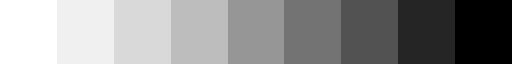

In [29]:
cmap

In [30]:
custom_palette = [mpl.colors.rgb2hex(cmap(i)) for i in range(cmap.N)]

In [31]:
custom_palette=custom_palette[2:-3]

In [32]:
scores = pd.DataFrame(scores_to_df)

scores = scores.T

In [33]:
scores = scores.reset_index().melt(id_vars='index', var_name='Metric', value_name='Score')

In [34]:
scores = scores.rename(columns={'index': 'Scenario'})

In [35]:
scores['Scenario'] = scores['Scenario'].astype('category')

In [36]:
scores['Metric'] = scores['Metric'].map({'max_nmi': 'Full-range max NMI', 'max_ari': 'Full-range max ARI', 'max_nmi_range': 'Bounded max NMI', 'max_ari_range': 'Bounded max ARI', 'nmi_kmeans': 'NMI kmeans', 'ari_kmeans': 'ARI kmeans'})

In [37]:
scores['Scenario'] = scores['Scenario'].map({'Liam_x5_minimal_example': 'Optimized', 'Liam_x1_minimal_example': 'Effective', 'naiveIntegration_minimal_example': 'Suboptimal', 'noIntegration_minimal_example': 'None'})
scores['Scenario'] = scores['Scenario'].cat.reorder_categories(['None', 'Suboptimal', 'Effective', 'Optimized'], ordered=True)



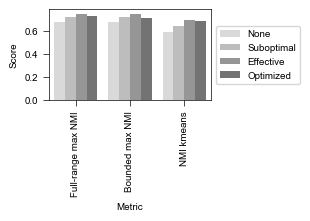

In [38]:
fig, ax = plt.subplots()
fig = sns.barplot(data=scores[(scores['Metric'] == 'Full-range max NMI') | (scores["Metric"] == 'Bounded max NMI') | (scores["Metric"] == 'NMI kmeans')], x='Metric', y='Score', hue='Scenario', palette=custom_palette)
plt.xticks(rotation=90)
ax.tick_params(axis='x', which='major', width=0.5, length=4)
ax.tick_params(axis='y', which='major', width=0.5, length=4)
fig.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.savefig('./../../figures/{}_clustering_choice_impact_nmi_rev1.png'.format('real_data_minimal_example'), format='png', dpi=600, bbox_inches='tight')

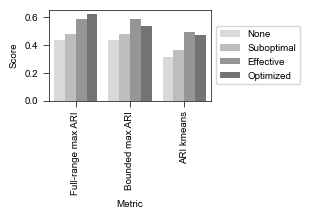

In [39]:
fig, ax = plt.subplots()
fig = sns.barplot(data=scores[(scores['Metric'] == 'Full-range max ARI') | (scores["Metric"] == 'Bounded max ARI')| (scores["Metric"] == 'ARI kmeans')], x='Metric', y='Score', hue='Scenario', palette=custom_palette)
plt.xticks(rotation=90)
ax.tick_params(axis='x', which='major', width=0.5, length=4)
ax.tick_params(axis='y', which='major', width=0.5, length=4)
fig.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.savefig('./../../figures/{}_clustering_choice_impact_ari_rev1.png'.format('real_data_minimal_example'), format='png', dpi=600, bbox_inches='tight')